In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
%cd /content/drive/MyDrive/DL
!ls

/content/drive/MyDrive/DL
 both.ipynb		'Copy of both (1).ipynb'   dataset_transport
 CNN.ipynb		'Copy of both.ipynb'	   TL.ipynb
 cnn_model_training.py	 data_augmentation.py	   transfer_learning.py


In [4]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

def create_train_generator(train_dir, target_size=(32, 32), batch_size=256):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # Use this to split training data into training and validation sets
    )

    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=target_size,
        batch_size=batch_size,
        shuffle=True,
        class_mode='categorical',
        subset='training'  # Use this to specify the training subset
    )

    return train_generator

def create_validation_generator(train_dir, target_size=(32, 32), batch_size=256):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # Use this to split training data into training and validation sets
    )

    validation_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=target_size,
        batch_size=batch_size,
        shuffle=True,
        class_mode='categorical',
        subset='validation'  # Use this to specify the validation subset
    )

    return validation_generator

def create_test_generator(test_dir, target_size=(32, 32), batch_size=256):
    test_datagen = ImageDataGenerator(rescale=1./255)

    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=target_size,
        batch_size=batch_size,
        shuffle=False,
        class_mode='categorical'
    )

    return test_generator

def print_class_examples(data_generator):
    # Get the mapping from class indices to class labels
    class_labels = data_generator.class_indices

    # Print one image from each class
    for class_label, class_index in class_labels.items():
        # Get the indices of all the images in the class
        indices = np.where(data_generator.classes == class_index)[0]
        if len(indices) > 0:
            # Get the filename of the first image in the class
            filename = data_generator.filenames[indices[0]]
            print(f"Filename: {filename}, Class Label: {class_label}, Class Number: {class_index}")
        else:
            print(f"No images found for class: {class_label}")

if __name__ == "__main__":
    # Directories for train and test datasets
    train_dir = 'dataset_transport/dataset_transport/train'
    test_dir = 'dataset_transport/dataset_transport/test'

    train_generator = create_train_generator(train_dir)
    validation_generator = create_validation_generator(train_dir)
    test_generator = create_test_generator(test_dir)

    print("Train generator:", train_generator)
    print("Validation generator:", validation_generator)
    print("Test generator:", test_generator)

Found 4800 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.
Found 1510 images belonging to 3 classes.
Train generator: <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x7a004b990f10>
Validation generator: <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x7a003b33df90>
Test generator: <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x7a003bc7a310>


##CNN

### CNN base

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


In [ ]:
# Directories for train and test datasets
train_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/train'
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'

In [ ]:
train_generator = create_train_generator(train_dir)
validation_generator = create_validation_generator(train_dir)

Found 4800 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.


In [ ]:
model = Sequential([
    Conv2D(32, 3, padding='same',activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 372,931 (1.42 MB)

 Trainable params: 372,931 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 878s 47s/step - accuracy: 0.3979 - loss: 1.0774 - val_accuracy: 0.5783 - val_loss: 0.9362
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5456 - loss: 0.9524 - val_accuracy: 0.5883 - val_loss: 0.8854
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5715 - loss: 0.9124 - val_accuracy: 0.6167 - val_loss: 0.8459
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5997 - loss: 0.8702 - val_accuracy: 0.6383 - val_loss: 0.7872
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6338 - loss: 0.8094 - val_accuracy: 0.6625 - val_loss: 0.7777
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6436 - loss: 0.8103 - val_accuracy: 0.6842 - val_loss: 0.7173
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6782 - loss: 0.7400 - val_accuracy: 0.6892 - val_loss: 0.6930
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6693 - loss: 0.7322 - val_accuracy: 0.7200 - val_los

In [ ]:
!mkdir /content/drive/'MyDrive'/saved_models

mkdir: cannot create directory ‘/content/drive/MyDrive/saved_models’: File exists


In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/saved_models/cnn_model6_234733T.h5')

In [ ]:
# Print class labels
print_class_examples(train_generator)

Filename: airplane/0401.png, Class Label: airplane, Class Number: 0
Filename: automobile/0401.png, Class Label: automobile, Class Number: 1
Filename: truck/0401.png, Class Label: truck, Class Number: 2


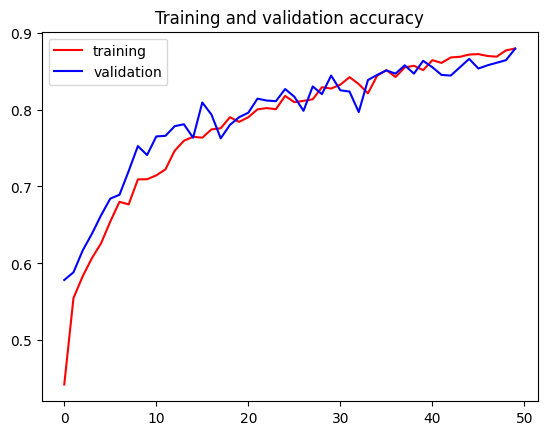

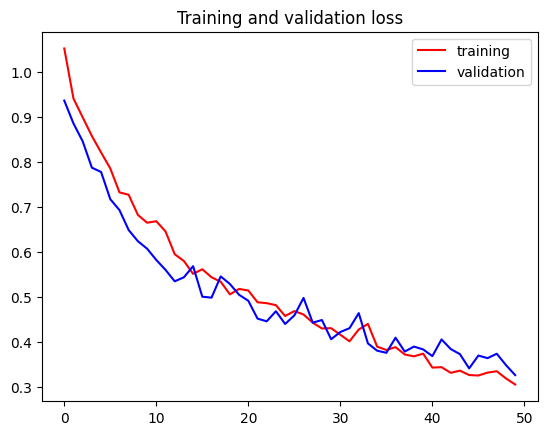

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Retrieve accuracy results for training and validation sets for each epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve loss results for training and validation sets for each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, 'r', label='training')         # Training accuracy (red)
plt.plot(epochs, val_acc, 'b', label='validation')   # Validation accuracy (blue)
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, 'r', label='training')       # Training loss (red)
plt.plot(epochs, val_loss, 'b', label='validation') # Validation loss (blue)
plt.title('Training and validation loss')
plt.legend()


In [ ]:
# Convert final accuracy to percentage and print
final_acc_percentage = 100 * acc[-1]  # Get the final accuracy and multiply by 100
print("Final Training Accuracy: {:.2f}%".format(final_acc_percentage))

final_val_acc_percentage = 100 * val_acc[-1]  # Get the final validation accuracy and multiply by 100
print("Final Validation Accuracy: {:.2f}%".format(final_val_acc_percentage))

Final Training Accuracy: 87.94%
Final Validation Accuracy: 87.92%


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


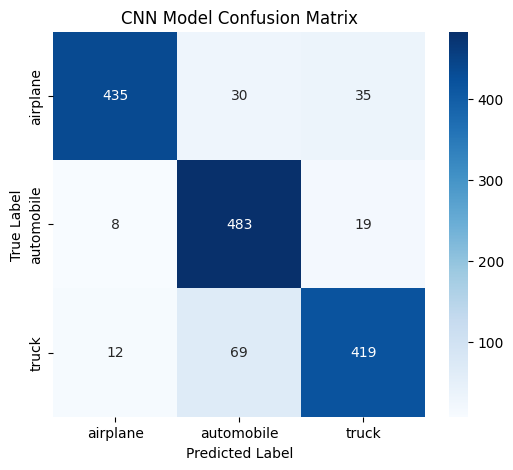

Classification Report:

              precision    recall  f1-score   support

    airplane       0.96      0.87      0.91       500
  automobile       0.83      0.95      0.88       510
       truck       0.89      0.84      0.86       500

    accuracy                           0.89      1510
   macro avg       0.89      0.89      0.89      1510
weighted avg       0.89      0.89      0.89      1510



In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load Model
model_path = '/content/drive/MyDrive/saved_models/cnn_model6_234733T.h5'  # Change as needed
model = tf.keras.models.load_model(model_path)

# Define test directory
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'


# labels & class names
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Model Predictions
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_matrix, "CNN Model Confusion Matrix", class_labels)

# Classification Report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average="weighted")
recall = recall_score(true_labels, predicted_labels, average="weighted")
f1 = f1_score(true_labels, predicted_labels, average="weighted")


###CNN fine tune

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


In [5]:
# Directories for train and test datasets
train_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/train'
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'

In [6]:
train_generator = create_train_generator(train_dir)
validation_generator = create_validation_generator(train_dir)

Found 4800 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.


In [7]:
model = Sequential([
    Conv2D(32, 3, padding='same',activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 372,931 (1.42 MB)

 Trainable params: 372,931 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer=Adam(learning_rate=0.0015), loss='categorical_crossentropy', metrics=['accuracy'])


In [13]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1489s 79s/step - accuracy: 0.3997 - loss: 1.0746 - val_accuracy: 0.5500 - val_loss: 0.9312
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.5534 - loss: 0.9317 - val_accuracy: 0.5917 - val_loss: 0.8773
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.5715 - loss: 0.8982 - val_accuracy: 0.6283 - val_loss: 0.8245
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.6380 - loss: 0.8181 - val_accuracy: 0.6242 - val_loss: 0.8121
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.6437 - loss: 0.7947 - val_accuracy: 0.6975 - val_loss: 0.6903
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6847 - loss: 0.7300 - val_accuracy: 0.6908 - val_loss: 0.6903
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6905 - loss: 0.7075 - val_accuracy: 0.6875 - val_loss: 0.6814
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6908 - loss: 0.7129 - val_accuracy: 0.7342 - val_lo

In [14]:
!mkdir /content/drive/'MyDrive'/saved_models

mkdir: cannot create directory ‘/content/drive/MyDrive/saved_models’: File exists


In [15]:
# Save the trained model
model.save('/content/drive/MyDrive/saved_models/cnn_model_finetune1_234733T.h5')

In [16]:
# Print class labels
print_class_examples(train_generator)

Filename: airplane/0401.png, Class Label: airplane, Class Number: 0
Filename: automobile/0401.png, Class Label: automobile, Class Number: 1
Filename: truck/0401.png, Class Label: truck, Class Number: 2


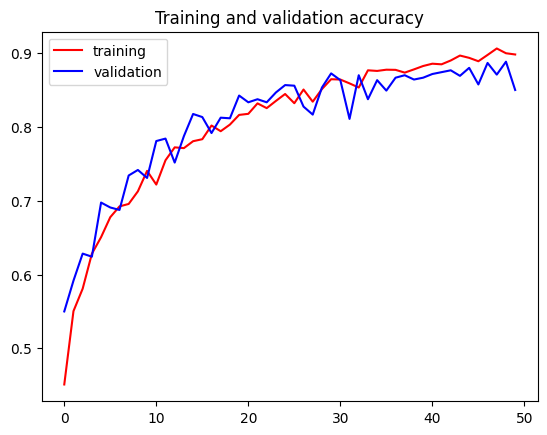

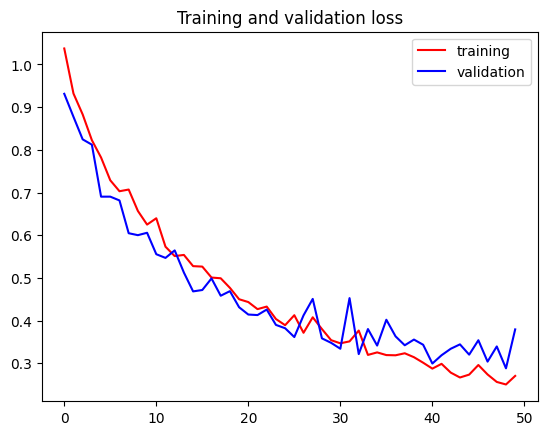

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

# Retrieve accuracy results for training and validation sets for each epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve loss results for training and validation sets for each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, 'r', label='training')         # Training accuracy (red)
plt.plot(epochs, val_acc, 'b', label='validation')   # Validation accuracy (blue)
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, 'r', label='training')       # Training loss (red)
plt.plot(epochs, val_loss, 'b', label='validation') # Validation loss (blue)
plt.title('Training and validation loss')
plt.legend()


In [18]:
# Convert final accuracy to percentage and print
final_acc_percentage = 100 * acc[-1]  # Get the final accuracy and multiply by 100
print("Final Training Accuracy: {:.2f}%".format(final_acc_percentage))

final_val_acc_percentage = 100 * val_acc[-1]  # Get the final validation accuracy and multiply by 100
print("Final Validation Accuracy: {:.2f}%".format(final_val_acc_percentage))

Final Training Accuracy: 89.81%
Final Validation Accuracy: 85.00%


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 861ms/step


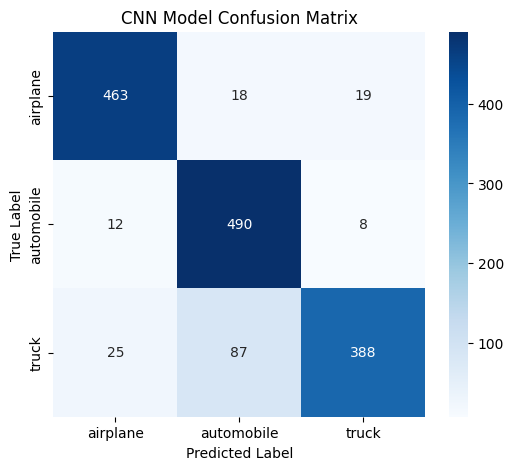

Classification Report:

              precision    recall  f1-score   support

    airplane       0.93      0.93      0.93       500
  automobile       0.82      0.96      0.89       510
       truck       0.93      0.78      0.85       500

    accuracy                           0.89      1510
   macro avg       0.89      0.89      0.89      1510
weighted avg       0.89      0.89      0.89      1510



In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load Model
model_path = '/content/drive/MyDrive/saved_models/cnn_model_finetune1_234733T.h5'  # Change as needed
model = tf.keras.models.load_model(model_path)

# Define test directory
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'


# labels & class names
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Model Predictions
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_matrix, "CNN Model Confusion Matrix", class_labels)

# Classification Report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average="weighted")
recall = recall_score(true_labels, predicted_labels, average="weighted")
f1 = f1_score(true_labels, predicted_labels, average="weighted")


## Summary of CNN model

For CNN model consist of 4 Conv2D layers from 32 to 128. The increase of neurons for each layer from detect simple patterns to capture meaningful features for the model to learn.
Overfitting is prevented through techniques like dropout (0.2)  20% of neurons randomly.
Creating train, validation , test generator to split the data. The validation subset that is create from training directory, helps monitor model performance without using test data during training.
Data regularization use ImageDataGenerator to apply transformations to expand dataset and reduce overfitting.
Normalization use to rescales pixels value to normalize them between 0 and 1 to improve training stability.
Batch size 256 is to reduce training time and smooth gradient updates.
Functions for generator, data regularization, normalization to have consistency for all the models.
A higher learning rate is applied to improve accuracy for tuning.
Maxpooling2D to reduce dimensionality and still perserving the important features.


##TF learning ###

#### MobileNetV2 ####

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout,GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [ ]:
# Define for train and test datasets
train_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/train'
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'

In [ ]:
train_generator = create_train_generator(train_dir)
validation_generator = create_validation_generator(train_dir)

Found 4800 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.


In [ ]:
# Load pre-trained MobileNetV2 model + higher level layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

<ipython-input-7-3ed8fceb5aca>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# UnFreeze the base model
for layer in base_model.layers:
    layer.trainable = True

# Create new model on top
x=base_model.output
x=GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x=Dense(256,activation='relu')(x)
preds=Dense(3,activation='softmax')(x)

model=Model(inputs=base_model.input, outputs=preds)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.00015), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 32, 32, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 16, 16, 32)     │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 16, 16, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 16, 16, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 16, 16, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 16, 16, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 16, 16, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 16, 16, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 16, 16, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 16, 16, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 16, 16, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 16, 16, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 17, 17, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 8, 8, 96)       │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 2,552,579 (9.74 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1311s 68s/step - accuracy: 0.3521 - loss: 1.5936 - val_accuracy: 0.3392 - val_loss: 1.1000
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5123 - loss: 1.0909 - val_accuracy: 0.3583 - val_loss: 1.0972
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5521 - loss: 0.9642 - val_accuracy: 0.4058 - val_loss: 1.0850
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5979 - loss: 0.8942 - val_accuracy: 0.4000 - val_loss: 1.0734
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6419 - loss: 0.8100 - val_accuracy: 0.4242 - val_loss: 1.0697
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6667 - loss: 0.7492 - val_accuracy: 0.3925 - val_loss: 1.1205
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6826 - loss: 0.7251 - val_accuracy: 0.3992 - val_loss: 1.1602
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7027 - loss: 0.7106 - val_accuracy: 0.4017 - val_lo

In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/saved_models/MobileNetV2model2_234733T.h5')

In [ ]:
# Print class labels
print_class_examples(train_generator)

Filename: airplane/0401.png, Class Label: airplane, Class Number: 0
Filename: automobile/0401.png, Class Label: automobile, Class Number: 1
Filename: truck/0401.png, Class Label: truck, Class Number: 2


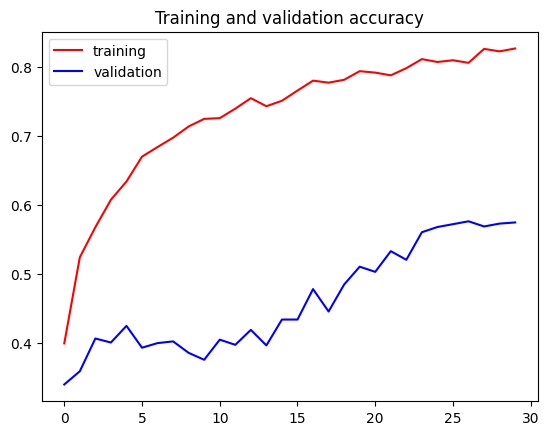

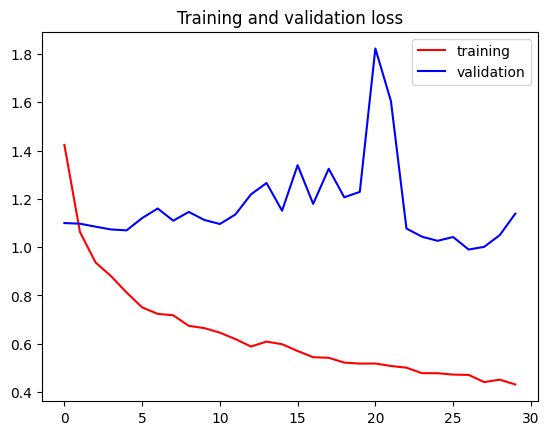

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Retrieve accuracy results for training and validation sets for each epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve loss results for training and validation sets for each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, 'r', label='training')         # Training accuracy (red)
plt.plot(epochs, val_acc, 'b', label='validation')   # Validation accuracy (blue)
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, 'r', label='training')       # Training loss (red)
plt.plot(epochs, val_loss, 'b', label='validation') # Validation loss (blue)
plt.title('Training and validation loss')
plt.legend()


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 938ms/step


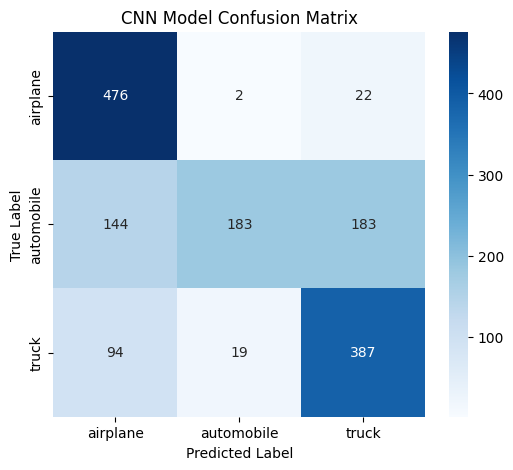

Classification Report:

              precision    recall  f1-score   support

    airplane       0.67      0.95      0.78       500
  automobile       0.90      0.36      0.51       510
       truck       0.65      0.77      0.71       500

    accuracy                           0.69      1510
   macro avg       0.74      0.69      0.67      1510
weighted avg       0.74      0.69      0.67      1510



In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load Model
model_path = '/content/drive/MyDrive/saved_models/MobileNetV2model2_234733T.h5'  # Change as needed
model = tf.keras.models.load_model(model_path)

# Define test directory
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'


# labels & class names
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Model Predictions
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_matrix, "CNN Model Confusion Matrix", class_labels)

# Classification Report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average="weighted")
recall = recall_score(true_labels, predicted_labels, average="weighted")
f1 = f1_score(true_labels, predicted_labels, average="weighted")


### VVG16 ##

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout,GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam




In [ ]:
# Define for train and test datasets
train_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/train'
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'

In [ ]:
train_generator = create_train_generator(train_dir)
validation_generator = create_validation_generator(train_dir)

Found 4800 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.


In [ ]:
# Load pre-trained VGG16 model + higher level layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# UnFreeze the base model
for layer in base_model.layers:
    layer.trainable = True


# Create new model on top
x=base_model.output
x=GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x=Dense(256,activation='relu')(x)
preds=Dense(3,activation='softmax')(x)

model=Model(inputs=base_model.input, outputs=preds)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │              

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 14,846,787 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1227s 64s/step - accuracy: 0.3371 - loss: 2.3948 - val_accuracy: 0.3333 - val_loss: 1.0959
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 637s 34s/step - accuracy: 0.3630 - loss: 1.0964 - val_accuracy: 0.4483 - val_loss: 1.0520
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 630s 33s/step - accuracy: 0.4181 - loss: 1.0545 - val_accuracy: 0.4850 - val_loss: 0.9565
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 628s 33s/step - accuracy: 0.4703 - loss: 0.9743 - val_accuracy: 0.5100 - val_loss: 0.8680
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 628s 34s/step - accuracy: 0.5304 - loss: 0.8903 - val_accuracy: 0.5017 - val_loss: 0.9028
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 656s 34s/step - accuracy: 0.5108 - loss: 0.8906 - val_accuracy: 0.5558 - val_loss: 0.8549
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 633s 33s/step - accuracy: 0.5436 - loss: 0.8642 - val_accuracy: 0.5358 - val_loss: 0.8337
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 683s 33s/step - accuracy: 0.5548 - loss: 0.8333 - val_accuracy: 0

In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/saved_models/VVG16model_234733T.h5')

In [ ]:
# Print class labels
print_class_examples(train_generator)

Filename: airplane/0401.png, Class Label: airplane, Class Number: 0
Filename: automobile/0401.png, Class Label: automobile, Class Number: 1
Filename: truck/0401.png, Class Label: truck, Class Number: 2


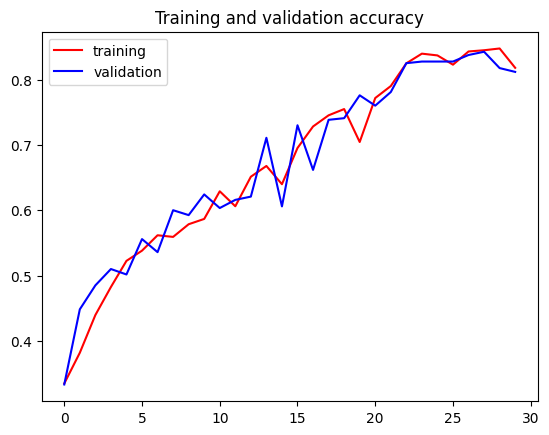

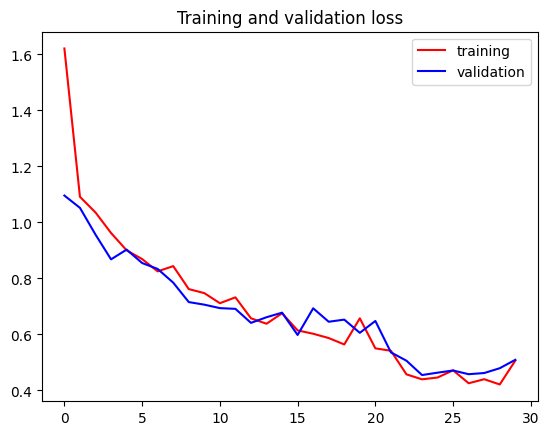

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Retrieve accuracy results for training and validation sets for each epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve loss results for training and validation sets for each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, 'r', label='training')         # Training accuracy (red)
plt.plot(epochs, val_acc, 'b', label='validation')   # Validation accuracy (blue)
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, 'r', label='training')       # Training loss (red)
plt.plot(epochs, val_loss, 'b', label='validation') # Validation loss (blue)
plt.title('Training and validation loss')
plt.legend()


6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step


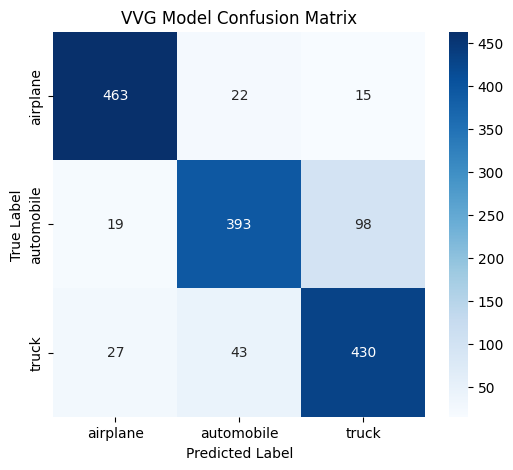

Classification Report:

              precision    recall  f1-score   support

    airplane       0.91      0.93      0.92       500
  automobile       0.86      0.77      0.81       510
       truck       0.79      0.86      0.82       500

    accuracy                           0.85      1510
   macro avg       0.85      0.85      0.85      1510
weighted avg       0.85      0.85      0.85      1510



In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load Model
model_path = '/content/drive/MyDrive/saved_models/VVG16model_234733T.h5'  # Change as needed
model = tf.keras.models.load_model(model_path)

# Define test directory
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'


# labels & class names
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Model Predictions
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_matrix, "VVG Model Confusion Matrix", class_labels)

# Classification Report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average="weighted")
recall = recall_score(true_labels, predicted_labels, average="weighted")
f1 = f1_score(true_labels, predicted_labels, average="weighted")


### VVG16 Fine tunning ###

#### VVG16 Fine tunning(low learning rate) ####

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout,GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam




In [ ]:
# Define for train and test datasets
train_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/train'
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'

In [ ]:
train_generator = create_train_generator(train_dir)
validation_generator = create_validation_generator(train_dir)

Found 4800 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.


In [ ]:
# Load pre-trained VGG16 model + higher level layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

In [ ]:
# UnFreeze the base model
for layer in base_model.layers:
    layer.trainable = True


# Create new model on top
x=base_model.output
x=GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x=Dense(256,activation='relu')(x)
preds=Dense(3,activation='softmax')(x)

model=Model(inputs=base_model.input, outputs=preds)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Print model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │              

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 14,846,787 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1546s 81s/step - accuracy: 0.3903 - loss: 1.1179 - val_accuracy: 0.6400 - val_loss: 0.8355
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 624s 33s/step - accuracy: 0.6200 - loss: 0.8424 - val_accuracy: 0.7442 - val_loss: 0.6415
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 578s 30s/step - accuracy: 0.7038 - loss: 0.6914 - val_accuracy: 0.7875 - val_loss: 0.5639
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 542s 28s/step - accuracy: 0.7542 - loss: 0.5962 - val_accuracy: 0.8183 - val_loss: 0.4730
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 612s 32s/step - accuracy: 0.7928 - loss: 0.5125 - val_accuracy: 0.8325 - val_loss: 0.4299
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 651s 34s/step - accuracy: 0.8088 - loss: 0.4743 - val_accuracy: 0.8358 - val_loss: 0.4141
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 679s 34s/step - accuracy: 0.8202 - loss: 0.4589 - val_accuracy: 0.8250 - val_loss: 0.4435
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 625s 33s/step - accuracy: 0.8275 - loss: 0.4196 - val_accuracy: 0

In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/saved_models/VVG_Model_low_234733T.h5')

In [ ]:
# Print class labels
print_class_examples(train_generator)

Filename: airplane/0401.png, Class Label: airplane, Class Number: 0
Filename: automobile/0401.png, Class Label: automobile, Class Number: 1
Filename: truck/0401.png, Class Label: truck, Class Number: 2


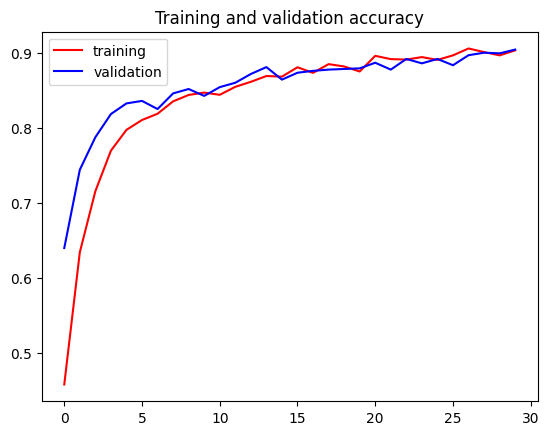

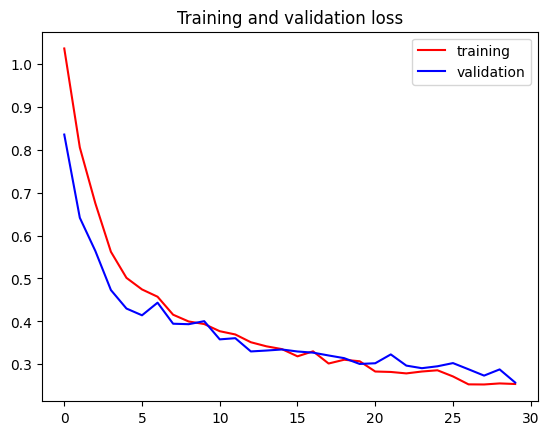

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Retrieve accuracy results for training and validation sets for each epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve loss results for training and validation sets for each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, 'r', label='training')         # Training accuracy (red)
plt.plot(epochs, val_acc, 'b', label='validation')   # Validation accuracy (blue)
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, 'r', label='training')       # Training loss (red)
plt.plot(epochs, val_loss, 'b', label='validation') # Validation loss (blue)
plt.title('Training and validation loss')
plt.legend()


6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step


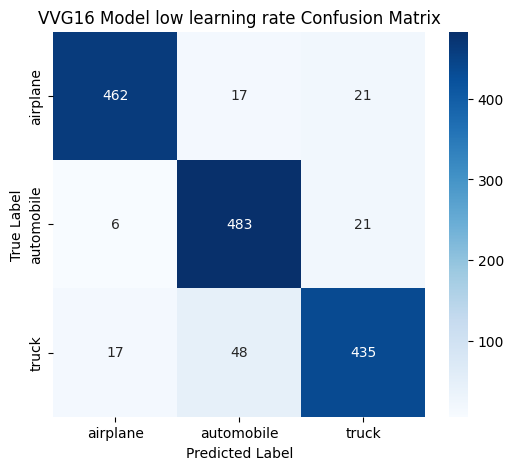

Classification Report:

              precision    recall  f1-score   support

    airplane       0.95      0.92      0.94       500
  automobile       0.88      0.95      0.91       510
       truck       0.91      0.87      0.89       500

    accuracy                           0.91      1510
   macro avg       0.92      0.91      0.91      1510
weighted avg       0.92      0.91      0.91      1510



In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load Model
model_path = '/content/drive/MyDrive/saved_models/VVG_Model_low_234733T.h5'  # Change as needed
model = tf.keras.models.load_model(model_path)

# Define test directory
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'


# labels & class names
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Model Predictions
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_matrix, "VVG16 Model low learning rate Confusion Matrix", class_labels)

# Classification Report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average="weighted")
recall = recall_score(true_labels, predicted_labels, average="weighted")
f1 = f1_score(true_labels, predicted_labels, average="weighted")


#### VVG16 Fine tunning(high learning rate) but still lower than the default learning rate of adam  ####

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout,GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam




In [ ]:
# Define for train and test datasets
train_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/train'
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'

In [ ]:
train_generator = create_train_generator(train_dir)
validation_generator = create_validation_generator(train_dir)

Found 4800 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.


In [ ]:
# Load pre-trained VGG16 model + higher level layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# UnFreeze the base model
for layer in base_model.layers:
    layer.trainable = True

# Create new model on top
x=base_model.output
x=GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x=Dense(256,activation='relu')(x)
preds=Dense(3,activation='softmax')(x)

model=Model(inputs=base_model.input, outputs=preds)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │              

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 14,846,787 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1503s 80s/step - accuracy: 0.5270 - loss: 0.9633 - val_accuracy: 0.7042 - val_loss: 0.6758
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 574s 29s/step - accuracy: 0.7276 - loss: 0.6258 - val_accuracy: 0.7383 - val_loss: 0.5979
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 560s 30s/step - accuracy: 0.7883 - loss: 0.5234 - val_accuracy: 0.8475 - val_loss: 0.3935
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 554s 29s/step - accuracy: 0.8485 - loss: 0.3976 - val_accuracy: 0.8542 - val_loss: 0.3694
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 557s 29s/step - accuracy: 0.8663 - loss: 0.3388 - val_accuracy: 0.8867 - val_loss: 0.3138
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 574s 30s/step - accuracy: 0.8779 - loss: 0.3238 - val_accuracy: 0.8833 - val_loss: 0.3052
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 547s 29s/step - accuracy: 0.8815 - loss: 0.3139 - val_accuracy: 0.8908 - val_loss: 0.2872
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 547s 29s/step - accuracy: 0.8936 - loss: 0.2844 - val_accuracy: 0

In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/saved_models/VVG_model_high1_234733T.h5')

In [ ]:
# Print class labels
print_class_examples(train_generator)

Filename: airplane/0401.png, Class Label: airplane, Class Number: 0
Filename: automobile/0401.png, Class Label: automobile, Class Number: 1
Filename: truck/0401.png, Class Label: truck, Class Number: 2


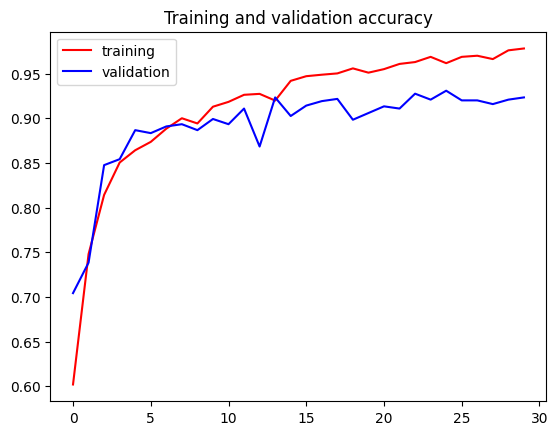

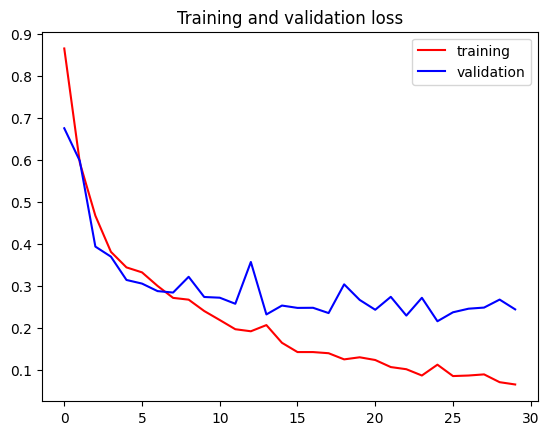

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Retrieve accuracy results for training and validation sets for each epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve loss results for training and validation sets for each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, 'r', label='training')         # Training accuracy (red)
plt.plot(epochs, val_acc, 'b', label='validation')   # Validation accuracy (blue)
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, 'r', label='training')       # Training loss (red)
plt.plot(epochs, val_loss, 'b', label='validation') # Validation loss (blue)
plt.title('Training and validation loss')
plt.legend()


6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


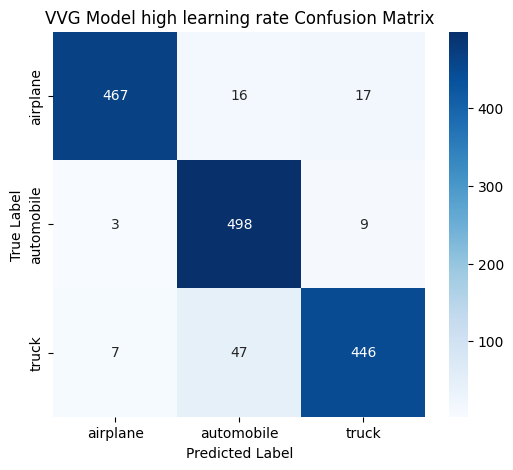

Classification Report:

              precision    recall  f1-score   support

    airplane       0.98      0.93      0.96       500
  automobile       0.89      0.98      0.93       510
       truck       0.94      0.89      0.92       500

    accuracy                           0.93      1510
   macro avg       0.94      0.93      0.93      1510
weighted avg       0.94      0.93      0.93      1510



In [36]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load Model
model_path = '/content/drive/MyDrive/saved_models/VVG_model_high1_234733T.h5'  # Change as needed
model = tf.keras.models.load_model(model_path)

# Define test directory
test_dir = '/content/drive/MyDrive/DL/dataset_transport/dataset_transport/test'


# labels & class names
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Model Predictions
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_matrix, "VVG Model high learning rate Confusion Matrix", class_labels)

# Classification Report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average="weighted")
recall = recall_score(true_labels, predicted_labels, average="weighted")
f1 = f1_score(true_labels, predicted_labels, average="weighted")


## Summary of Transfer Learning model

Both MobileNetV2 and VGG16 was selected for transfer learning as they have strong feature extraction capabilities. Both were trained with the same parameters, GlobalAveragePooling2D is added to speed up training and reduces overfitting while improving computational efficiency, and all layers were unfreeze to evaluate which model performed better.
MobileNetV2 did not generalize well, even with fine-tuning at a higher learning rate. Its validation accuracy remained low and inconsistent, indicating that it struggled to learn meaningful features from the 32 x 32 dataset.
VVG16 demonstrated better generalization, making it the preferred choice.
VGG16 was fine-tuned. One lower learning rate 0.00001 made small, gradual updates, preserving pre-trained weights and preventing overfitting, which is beneficial for small datasets. One higher learning rate 0.0001 allowed faster learning, making larger weight updates but risking the loss of pre-trained knowledge. Testing both learning rates helped determine the best balance between stability and adaptability for improved performance.


## Compare CNN & Transfer learning(VVG16) ##

Found 1510 images belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step


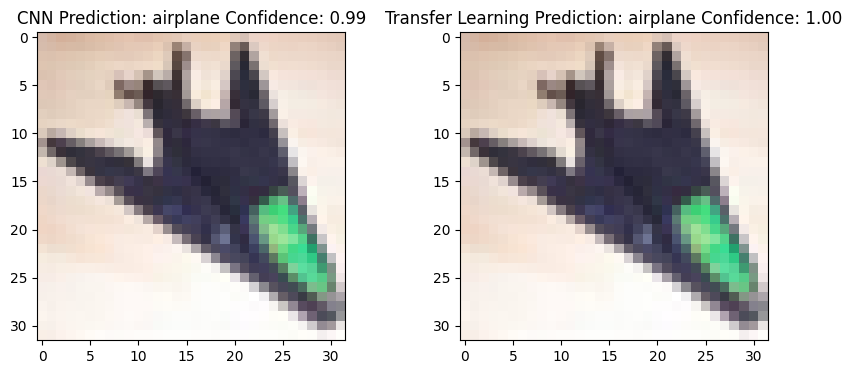

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


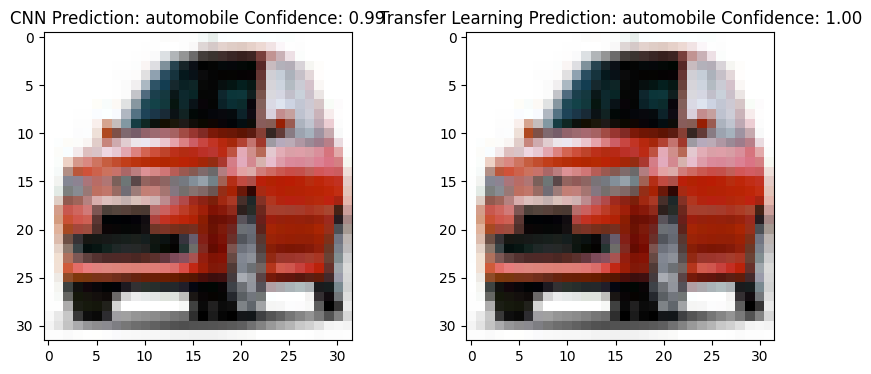

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


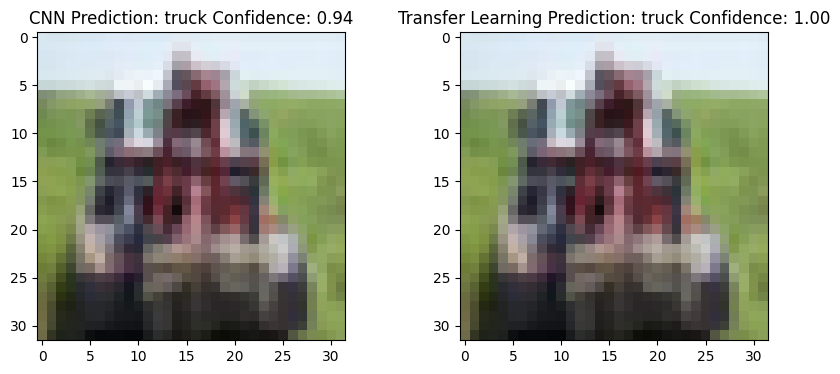

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step
CNN Model Classification Report:
               precision    recall  f1-score   support

    airplane       0.93      0.93      0.93       500
  automobile       0.82      0.96      0.89       510
       truck       0.93      0.78      0.85       500

    accuracy                           0.89      1510
   macro avg       0.89      0.89      0.89      1510
weighted avg       0.89      0.89      0.89      1510

Transfer Learning Model Classification Report:
               precision    recall  f1-score   support

    airplane       0.98      0.93      0.96       500
  automobile       0.89      0.98      0.93       510
       truck       0.94      0.89      0.92       500

    accuracy                           0.93      1510
   macro avg       0.94      0.93      0.93      1510
weighted avg       0.94      0.93      0.93      1510



In [37]:
import matplotlib.pyplot as plt
import PIL.Image as Image
import numpy as np
from sklearn.metrics import classification_report


cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/saved_models/cnn_model_finetune1_234733T.h5')
transfer_model = tf.keras.models.load_model('/content/drive/MyDrive/saved_models/VVG_model_high1_234733T.h5')

# Define class labels and corresponding image paths
class_labels = ['airplane', 'automobile', 'truck']
image_paths = {
    'airplane': 'dataset_transport/dataset_transport/test/airplane/0499.png',
    'automobile': 'dataset_transport/dataset_transport/test/automobile/0017.png',
    'truck': 'dataset_transport/dataset_transport/test/truck/0023.png'
}

# Define test directory
test_dir = 'dataset_transport/dataset_transport/test'
test_generator = create_test_generator(test_dir)

# Store the predictions for display
predictions = []

for label in class_labels:
    # Load and preprocess image for CNN model
    img = Image.open(image_paths[label]).resize((32, 32))
    img_array = np.array(img) / 255.0
    img_array = img_array[np.newaxis, ...]

    #predictions
    cnn_result = cnn_model.predict(img_array)
    transfer_result = transfer_model.predict(img_array)

    cnn_PD_class = np.argmax(cnn_result[0], axis=-1)
    TF_PD_class = np.argmax(transfer_result[0], axis=-1)

    cnn_confidence = cnn_result[0][cnn_PD_class]
    transfer_confidence = transfer_result[0][TF_PD_class]

    # plot
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"CNN Prediction: {class_labels[cnn_PD_class]} Confidence: {cnn_confidence:.2f}")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.title(f"Transfer Learning Prediction: {class_labels[TF_PD_class]} Confidence: {transfer_confidence:.2f}")

    plt.show()

    # Store predictions
    predictions.append({
        "class": label,
        "cnn_prediction": class_labels[cnn_PD_class],
        "cnn_confidence": cnn_confidence,
        "transfer_prediction": class_labels[TF_PD_class],
        "transfer_confidence": transfer_confidence
    })

# labels
T_label = test_generator.classes

# Make predictions
cnn_predictions = cnn_model.predict(test_generator)
cnn_pd_label = cnn_predictions.argmax(axis=1)
transfer_predictions = transfer_model.predict(test_generator)
TF_pd_label = transfer_predictions.argmax(axis=1)

# Classification reports
cnn_cr = classification_report(T_label, cnn_pd_label, target_names=test_generator.class_indices.keys())
transfer_cr = classification_report(T_label, TF_pd_label, target_names=test_generator.class_indices.keys())

# Print classification reports
print("CNN Model Classification Report:\n", cnn_cr)
print("Transfer Learning Model Classification Report:\n", transfer_cr)


Found 1510 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 981ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step


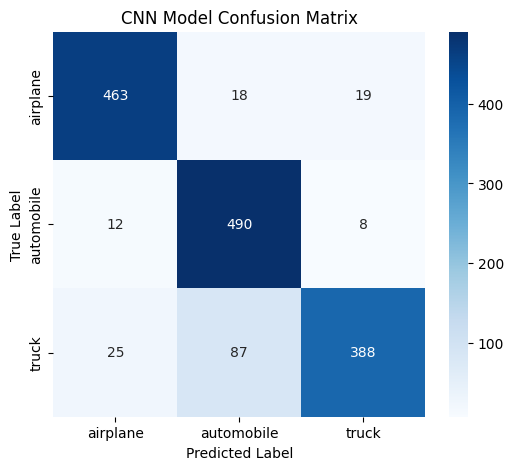

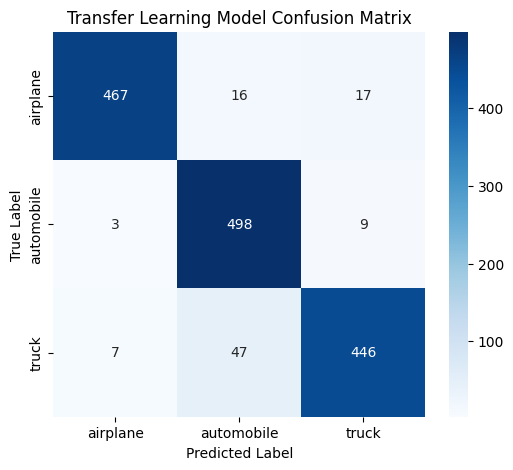

In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load  Model
cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/saved_models/cnn_model_finetune1_234733T.h5')
transfer_model = tf.keras.models.load_model('/content/drive/MyDrive/saved_models/VVG_model_high1_234733T.h5')



# Define test directory
test_dir = 'dataset_transport/dataset_transport/test'
test_generator = create_test_generator(test_dir)

#Labels
true_labels = test_generator.classes  # Get actual class labels
class_labels = list(test_generator.class_indices.keys())  # Get class names


# Predictions
cnn_predictions = cnn_model.predict(test_generator)
cnn_predicted_labels = np.argmax(cnn_predictions, axis=1)

transfer_predictions = transfer_model.predict(test_generator)
transfer_predicted_labels = np.argmax(transfer_predictions, axis=1)


#Confusion Matrices
cnn_conf_matrix = confusion_matrix(true_labels, cnn_predicted_labels)
transfer_conf_matrix = confusion_matrix(true_labels, transfer_predicted_labels)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()
plot_confusion_matrix(cnn_conf_matrix, "CNN Model Confusion Matrix", class_labels)
plot_confusion_matrix(transfer_conf_matrix, "Transfer Learning Model Confusion Matrix", class_labels)



## Summary Comparison of the 2 models CNN & Transfer learning(VVG16) ##

VGG16 was fine-tuned with two different learning rates, 0.00001 and 0.0001. The learning rate of 0.0001 was chosen as it resulted in better overall performance in the metrics.
The evaluation of CNN and Transfer Learning models, VGG16 showed that performed better in terms of accuracy and generalization due to pre-trained feature extraction.
CNN was built and training from scratch, whereas Transfer Learning leveraged pre-trained knowledge, making it more efficient. However, Transfer Learning models had higher computational demands. CNNs are more suitable when a custom architecture is needed, while Transfer Learning is ideal for leveraging existing knowledge for improved performance.

Overall, even though CNN achieved 83% and VVG16 achieved 93%. Even with different accuracy both faced the issue of predicting the trucks as seem in the classification report and confusion matrix. VVG16 is computattional power which took longer hours for training compared to CNN.



